In [2]:

!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install hdbscan
!pip install geopandas
!pip install contextily
!pip install shapely

import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
import contextily as ctx 
from shapely.geometry import point

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 13.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   --- ------------------------------------ 2.1/23.8 MB 9.3 MB/s eta 0:00:03
   -------- ------------------------------- 5.0/23.8 MB 12.0 MB/s eta 0:00:02
   ----------- ---------------------------- 7.1/23.8 MB 11.6 MB/s eta 0:00:02
   ---------------- ----------------------- 10.0/23.8 MB 11.9 MB/s eta 0:00:02
   ------------------- -------------------- 11.8/23.8 MB 11.4 MB/s eta 0:00:02
   ---------------------- ----------------- 13.1/23.8 MB 10.2 MB/s eta 0:00:02
   ------------------------- -------------- 15.2/23.8 MB 10.3 MB/s eta 0:00:01
   ----------------------------- ---------- 17.8/23.8 MB 10.7 MB/s eta 0:00:01
   ------------------------------------ --- 21.8/23.8 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------  23.6/23.8 MB 11.4 MB/s eta 0:00:0

In [3]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

Downloaded and extracted: Canada.tif


In [6]:
def plot_clustered_location(df,museum = 'Museums Clustered by Proximity'):

    gdf = gpd.GeoDataFrame(df,geometry = gpd.points_from_xy(df['Longitude'],df['Latitude']), crs="EPSG:4326")
    gdf = gdf.to_crs(epsg=3857)

    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == 1]
    # Plot noise points 
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
        
        # Plot clustered points, colured by 'Cluster' number
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)
        
        # Add basemap of  Canada
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)
        
        # Format plot
    plt.title(title, )
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
        
        # Show the plot
    plt.show()

In [7]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'

In [8]:
df = pd.read_csv(url,encoding = "ISO-8859-1")

In [9]:
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


In [10]:
df.isnull().sum()

Index                    0
Facility_Name            0
Source_Facility_Type     0
ODCAF_Facility_Type      0
Provider                 0
Unit                     0
Street_No                0
Street_Name              0
Postal_Code              0
City                     0
Prov_Terr                0
Source_Format_Address    0
CSD_Name                 0
CSDUID                   0
PRUID                    0
Latitude                 0
Longitude                0
dtype: int64

In [11]:
df.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64

In [13]:
df = df[df.ODCAF_Facility_Type == 'museum']
df.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
museum    1938
Name: count, dtype: int64

In [14]:
df =df[df.Latitude != '..']
df[['Latitude', 'Longitude']] = df[['Latitude', 'Longitude']].astype('float')
df[['Latitude', 'Longitude']]

,Latitude,Longitude
1,55.264551,-127.642812
2,45.963283,-66.641902
8,49.176354,-123.112783
13,49.261938,-123.151123
15,49.889559,-97.235744
...,...,...
7934,43.183090,-79.224564
7936,43.690022,-79.476208
7940,43.857692,-79.361940
7968,48.422420,-123.343553


Downloaded and extracted: Canada.tif
Cluster
 4     701
 2     192
 1     181
 7     134
 3      94
-1      79
 6      30
 10     27
 8      21
 11     15
 15     13
 20     11
 16     10
 19      9
 27      8
 12      7
 26      6
 5       6
 24      6
 28      6
 14      6
 18      6
 13      4
 9       4
 22      4
 0       3
 23      3
 21      3
 17      3
 25      3
 29      3
 31      3
 30      3
 32      3
Name: count, dtype: int64


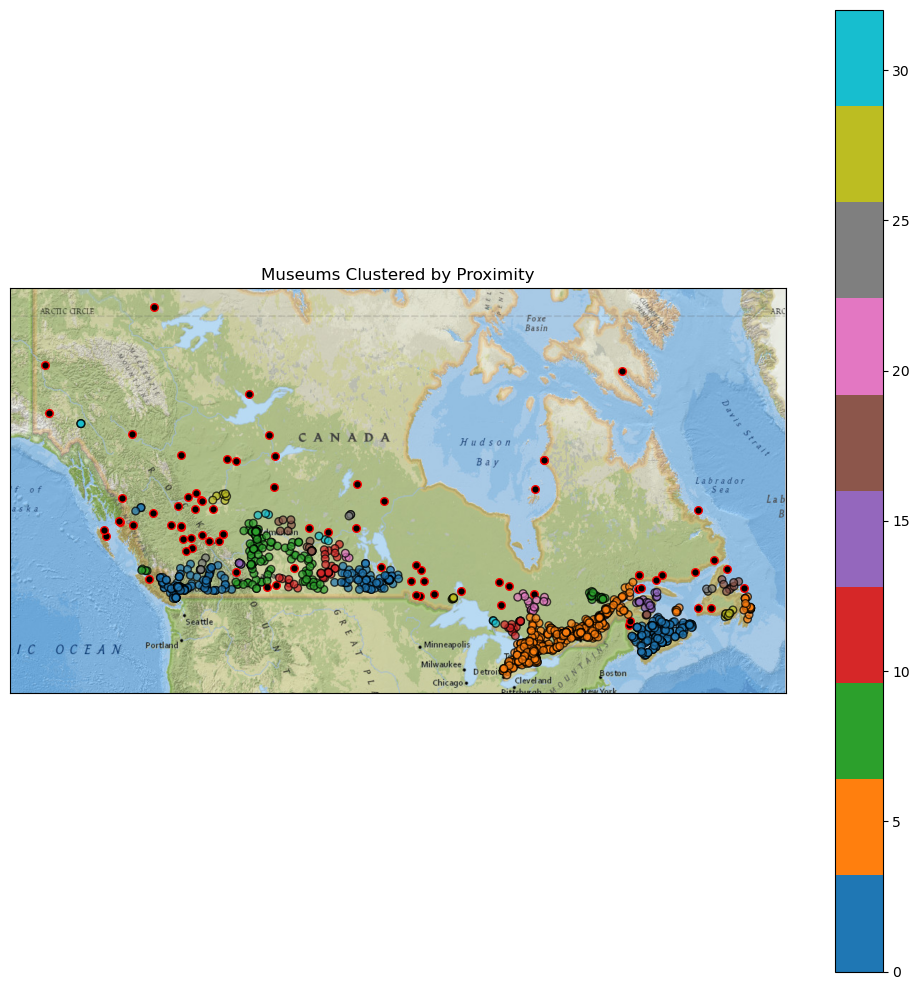

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler

import geopandas as gpd
import contextily as ctx
import requests
import zipfile
import io
import os

# -----------------------------
# Download Canada.tif
# -----------------------------
zip_file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip"

output_dir = "./"
os.makedirs(output_dir, exist_ok=True)

response = requests.get(zip_file_url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    for file_name in zip_ref.namelist():
        if file_name.endswith(".tif"):
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

# -----------------------------
# Function to Plot Clusters
# -----------------------------
def plot_clustered_location(df, title="Museums Clustered by Proximity"):

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
        crs="EPSG:4326"
    )

    gdf = gdf.to_crs(epsg=3857)

    non_noise = gdf[gdf["Cluster"] != -1]
    noise = gdf[gdf["Cluster"] == -1]

    # Plot noise
    if len(noise) > 0:
        noise.plot(
            ax=ax,
            color="black",
            markersize=30,
            edgecolor="red",
            alpha=1,
            label="Noise"
        )

    # Plot clustered points
    if len(non_noise) > 0:
        non_noise.plot(
            ax=ax,
            column="Cluster",
            cmap="tab10",
            markersize=30,
            edgecolor="black",
            legend=True,
            alpha=0.7
        )

    # Add Canada basemap
    ctx.add_basemap(ax, source="./Canada.tif", zoom=4)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# -----------------------------
# Load Museum Dataset
# -----------------------------
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv"

df = pd.read_csv(url, encoding="ISO-8859-1")

# Keep only museums
df = df[df["ODCAF_Facility_Type"] == "museum"]

# Remove missing coordinates
df = df[df["Latitude"] != ".."]

# Convert coordinates to float
df[["Latitude", "Longitude"]] = df[["Latitude", "Longitude"]].astype(float)

# -----------------------------
# Prepare Coordinates
# -----------------------------
coords_scaled = df[["Latitude", "Longitude"]].copy()

# Stretch latitude slightly
coords_scaled["Latitude"] = 2 * coords_scaled["Latitude"]

# -----------------------------
# DBSCAN Parameters
# -----------------------------
eps = 1.0
min_samples = 3
metric = "euclidean"

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric=metric
)

# Assign clusters
df["Cluster"] = dbscan.fit_predict(coords_scaled)

# Display cluster counts
print(df["Cluster"].value_counts())

# Plot result
plot_clustered_location(df)

In [2]:
min_samples=None
min_cluster_size=3
hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric='euclidean')  # You can adjust parameters as needed

In [3]:
df['Cluster'] = hdb.fit_predict(coords_scaled)  # Another way to assign the labels

# Display the size of each cluster
df['Cluster'].value_counts()

Cluster
-1      454
 137     44
 97      39
 58      35
 93      33
       ... 
 133      3
 39       3
 69       3
 47       3
 132      3
Name: count, Length: 141, dtype: int64

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler

import geopandas as gpd
import contextily as ctx
import requests
import zipfile
import io
import os

# -----------------------------
# Download Canada.tif
# -----------------------------
zip_file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip"

output_dir = "./"
os.makedirs(output_dir, exist_ok=True)

response = requests.get(zip_file_url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    for file_name in zip_ref.namelist():
        if file_name.endswith(".tif"):
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

# -----------------------------
# Function to Plot Clusters
# -----------------------------
def plot_clustered_location(df, title="Museums Clustered by Proximity"):

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
        crs="EPSG:4326"
    )

    gdf = gdf.to_crs(epsg=3857)

    non_noise = gdf[gdf["Cluster"] != -1]
    noise = gdf[gdf["Cluster"] == -1]

    # Plot noise
    if len(noise) > 0:
        noise.plot(
            ax=ax,
            color="black",
            markersize=30,
            edgecolor="red",
            alpha=1,
            label="Noise"
        )

    # Plot clustered points
    if len(non_noise) > 0:
        non_noise.plot(
            ax=ax,
            column="Cluster",
            cmap="tab10",
            markersize=30,
            edgecolor="black",
            legend=True,
            alpha=0.7
        )

    # Add Canada basemap
    ctx.add_basemap(ax, source="./Canada.tif", zoom=4)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# -----------------------------
# Load Museum Dataset
# -----------------------------
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv"

df = pd.read_csv(url, encoding="ISO-8859-1")

# Keep only museums
df = df[df["ODCAF_Facility_Type"] == "museum"]

# Remove missing coordinates
df = df[df["Latitude"] != ".."]

# Convert coordinates to float
df[["Latitude", "Longitude"]] = df[["Latitude", "Longitude"]].astype(float)

# -----------------------------
# Prepare Coordinates
# -----------------------------
coords_scaled = df[["Latitude", "Longitude"]].copy()

# Stretch latitude slightly
coords_scaled["Latitude"] = 2 * coords_scaled["Latitude"]

# -----------------------------
# DBSCAN Parameters
# -----------------------------
eps = 1.0
min_samples = 3
metric = "euclidean"

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric=metric
)

# Assign clusters
df["Cluster"] = dbscan.fit_predict(coords_scaled)

# Display cluster counts
print(df["Cluster"].value_counts())

min_samples=None
min_cluster_size=3
hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric='euclidean')

df['Cluster'] = hdb.fit_predict(coords_scaled)  # Another way to assign the labels

# Display the size of each cluster
df['Cluster'].value_counts()

# Plot result
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')

Downloaded and extracted: Canada.tif
Cluster
 4     701
 2     192
 1     181
 7     134
 3      94
-1      79
 6      30
 10     27
 8      21
 11     15
 15     13
 20     11
 16     10
 19      9
 27      8
 12      7
 26      6
 5       6
 24      6
 28      6
 14      6
 18      6
 13      4
 9       4
 22      4
 0       3
 23      3
 21      3
 17      3
 25      3
 29      3
 31      3
 30      3
 32      3
Name: count, dtype: int64


NameError: name 'plot_clustered_locations' is not defined